In [1]:
import zipfile
import os

# Extraire movies1000.zip
with zipfile.ZipFile('movies1000.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("Extraction OK")
print("Dossiers movies:", os.listdir('movies1000'))


Extraction OK
Dossiers movies: ['neg', 'pos']


# Projet RITAL 2025-2026 — Tâche 1 : Classification Chirac / Mitterrand

## Objectif
Classifier des phrases de discours présidentiels comme étant de **Chirac (C)** ou **Mitterrand (M)**.

- **Train** : `corpus.tache1.learn.utf8`
- **Test** : `corpus.tache1.test.utf8`
- **Format de soumission** : probabilité d'être Chirac par ligne (P < 0.5 → Chirac, P > 0.5 → Mitterrand)

## Approches testées
1. TF-IDF + Régression Logistique (baseline)
2. TF-IDF + SVM
3. TF-IDF + Naive Bayes
4. TF-IDF + Random Forest
5. Optimisation du meilleur modèle

---
**Auteurs** : Ahmed Walid BOUANZOUL & DEBZ Wail
**Date** : Mars 2026

## 1. Imports et Configuration

In [3]:
# Librairies standard
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

print("Imports OK")

Imports OK


## 2. Chargement des données

In [4]:
def load_presidents_train(filepath):
    texts, labels = [], []
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('<') and '>' in line:
                header = line[1:line.index('>')]
                text = line[line.index('>')+1:].strip()
                parts = header.split(':')
                if len(parts) == 3:
                    texts.append(text)
                    labels.append(parts[2])  # 'C' ou 'M'
    return texts, labels

def load_presidents_test(filepath):
    texts = []
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('<') and '>' in line:
                text = line[line.index('>')+1:].strip()
                texts.append(text)
    return texts

# Chargement
train_texts, train_labels = load_presidents_train('corpus.tache1.learn.utf8')
test_texts = load_presidents_test('corpus.tache1.test.utf8')

print(f"Train : {len(train_texts)} phrases")
print(f"Test  : {len(test_texts)} phrases")
print(f"Labels : {set(train_labels)}")

Train : 57413 phrases
Test  : 27162 phrases
Labels : {'M', 'C'}


## 3. Exploration des données

Distribution des classes :
  C : 49890 phrases (86.9%)
  M : 7523 phrases (13.1%)


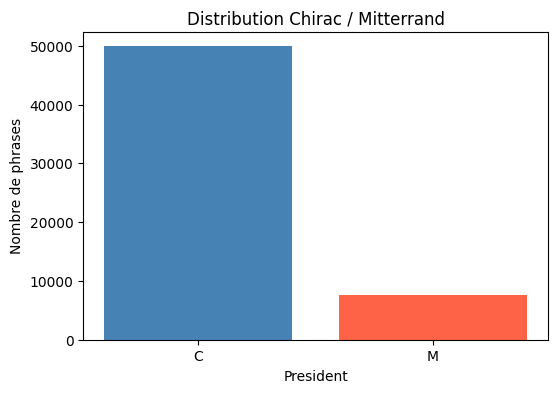


Longueur moyenne des phrases : 21.5 mots
Longueur min : 1 mots
Longueur max : 386 mots


In [5]:
# Distribution des classes
counter = Counter(train_labels)
print("Distribution des classes :")
for label, count in counter.items():
    print(f"  {label} : {count} phrases ({100*count/len(train_labels):.1f}%)")

# Visualisation
plt.figure(figsize=(6,4))
plt.bar(counter.keys(), counter.values(), color=['steelblue', 'tomato'])
plt.title("Distribution Chirac / Mitterrand")
plt.xlabel("President")
plt.ylabel("Nombre de phrases")
plt.show()

# Longueur moyenne des phrases
lengths = [len(t.split()) for t in train_texts]
print(f"\nLongueur moyenne des phrases : {np.mean(lengths):.1f} mots")
print(f"Longueur min : {min(lengths)} mots")
print(f"Longueur max : {max(lengths)} mots")

## 4. Preprocessing

In [8]:
import re

def preprocess(text):
    # Minuscules
    text = text.lower()
    # Supprimer les balises <nom> etc.
    text = re.sub(r'<[^>]+>', '', text)
    # Supprimer la ponctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    # Supprimer les chiffres
    text = re.sub(r'\d+', '', text)
    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Appliquer le preprocessing
train_texts_clean = [preprocess(t) for t in train_texts]
test_texts_clean  = [preprocess(t) for t in test_texts]

# Convertir labels en binaire : C=0, M=1
train_labels_bin = [0 if l == 'C' else 1 for l in train_labels]

# Verifier
print("Avant :", train_texts[0])
print("Apres :", train_texts_clean[0])
print("Label  :", train_labels[0], "->", train_labels_bin[0])

Avant : Quand je dis chers amis, il ne s'agit pas là d'une formule diplomatique, mais de l'expression de ce que je ressens.
Apres : quand je dis chers amis il ne s agit pas là d une formule diplomatique mais de l expression de ce que je ressens
Label  : C -> 0


## 5. Modèles de classification

### Stratégie
Le dataset est déséquilibré (86.9% Chirac). On utilise `class_weight='balanced'` 
pour corriger ce biais. On évalue chaque modèle en cross-validation (5 folds).

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

# Convertir labels en array numpy
y_train = np.array(train_labels_bin)

# Definir les modeles
models = {
    "LogisticRegression": Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=50000)),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),
    "LinearSVC": Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=50000)),
        ('clf', CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=1000)))
    ]),
    "NaiveBayes": Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=50000)),
        ('clf', MultinomialNB())
    ]),
}

# Evaluation en cross-validation
print("Evaluation des modeles (5-fold cross-validation) :\n")
results = {}
for name, model in models.items():
    scores = cross_val_score(model, train_texts_clean, y_train, cv=5, scoring='f1_macro')
    results[name] = scores.mean()
    print(f"{name:25s} -> F1 macro : {scores.mean():.4f} (+/- {scores.std():.4f})")

Evaluation des modeles (5-fold cross-validation) :

LogisticRegression        -> F1 macro : 0.7363 (+/- 0.0082)
LinearSVC                 -> F1 macro : 0.7299 (+/- 0.0064)
NaiveBayes                -> F1 macro : 0.4941 (+/- 0.0055)


## 6. Génération des soumissions

In [10]:
import os
import pandas as pd

os.makedirs('rital_tmp', exist_ok=True)

# Soumission 1 — LogisticRegression
model1 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=50000)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])
model1.fit(train_texts_clean, y_train)
probas1 = model1.predict_proba(test_texts_clean)[:, 0]  # proba d'etre Chirac
pd.DataFrame(probas1).to_csv('rital_tmp/submission-pres-1.csv', index=False, header=False)
print("submission-pres-1.csv genere :", len(probas1), "lignes")

# Soumission 2 — LinearSVC
model2 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=50000)),
    ('clf', CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=1000)))
])
model2.fit(train_texts_clean, y_train)
probas2 = model2.predict_proba(test_texts_clean)[:, 0]
pd.DataFrame(probas2).to_csv('rital_tmp/submission-pres-2.csv', index=False, header=False)
print("submission-pres-2.csv genere :", len(probas2), "lignes")

# Soumission 3 — LogisticRegression avec ngram (1,3)
model3 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,3), max_features=80000)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, C=5))
])
model3.fit(train_texts_clean, y_train)
probas3 = model3.predict_proba(test_texts_clean)[:, 0]
pd.DataFrame(probas3).to_csv('rital_tmp/submission-pres-3.csv', index=False, header=False)
print("submission-pres-3.csv genere :", len(probas3), "lignes")

print("\nToutes les soumissions presidents generees !")

submission-pres-1.csv genere : 27162 lignes
submission-pres-2.csv genere : 27162 lignes
submission-pres-3.csv genere : 27162 lignes

Toutes les soumissions presidents generees !
